# Tarea 2: Regresión no lineal y MLE

MDS7104: Aprendizaje de Maquinas - Otoño 2026

---

### Cuerpo Docente:

- Profesor: Francisco Vásquez L.
- Auxiliares: Álvaro Márquez y Diego Olguín Wende
- Ayudantes: Javiera Yañez y Tamara Carrasco


### Estudiante

- Felipe Muñoz M.

# a) Exploración de datos

In [ ]:
!uv add numpy requests pandas matplotlib scipy scikit-learn ruff pre-commit

In [2]:
!uv add ipykernel ipython matplotlib-inline

Resolved 63 packages in 25ms
Audited 58 packages in 12ms


In [3]:
import os

os.environ.pop("MPLBACKEND", None)

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

In [5]:
%matplotlib inline

In [ ]:
import json

import pandas as pd

Se procede a importar la base de datos desde mi repositorio en Github

In [ ]:
# Clonar el repo completo con LFS
#!git lfs install
#!git clone https://github.com/FeLiJaNdRo/MDS7104-ML.git

In [ ]:
# Cargar el archivo en Google Colab
# with open('/Users/felijandro/Documents/Universidad/12voSemestre/AprendizajedeMaquinas/MDS7104-ML/tareas/tarea1/Musical_Instruments.jsonl', 'r') as f:
#    data = [json.loads(line) for line in f]
# df = pd.DataFrame(data)

In [ ]:
# Se abre el Dataframe
with open("data_t2_p2.json") as f:
    data = json.load(f)

In [ ]:
# Se guardan los datasets de acuerdo a su frecuencia (daily, weekly, monthly)

df_daily = pd.DataFrame(data["daily"]["data"])
df_weekly = pd.DataFrame(data["weekly"]["data"])
df_monthly = pd.DataFrame(data["monthly"]["data"])

# daily y monthly sí tienen "date"
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_monthly["date"] = pd.to_datetime(df_monthly["date"])

# weekly tiene "week_start" y "week_end"
df_weekly["week_start"] = pd.to_datetime(df_weekly["week_start"])
df_weekly["week_end"] = pd.to_datetime(df_weekly["week_end"])

df_daily = df_daily.sort_values("date").reset_index(drop=True)
df_weekly = df_weekly.sort_values("week_start").reset_index(drop=True)
df_monthly = df_monthly.sort_values("date").reset_index(drop=True)

,index,date,review_count
0,1,2009-01-01,0
1,2,2009-01-02,0
2,3,2009-01-03,1
3,4,2009-01-04,0
4,5,2009-01-05,3


In [17]:
frec = ["daily", "weekly", "monthly"]
for f in frec:
    print(f"Dataset: {f}")
    display(globals()[f"df_{f}"].head())

Dataset: daily


,index,date,review_count
0,1,2009-01-01,0
1,2,2009-01-02,0
2,3,2009-01-03,1
3,4,2009-01-04,0
4,5,2009-01-05,3


Dataset: weekly


,index,week_start,week_end,review_count
0,1,2008-12-29,2009-01-04,1
1,2,2009-01-05,2009-01-11,14
2,3,2009-01-12,2009-01-18,5
3,4,2009-01-19,2009-01-25,2
4,5,2009-01-26,2009-02-01,5


Dataset: monthly


,index,year,month,date,review_count
0,1,2009,1,2009-01-01,27
1,2,2009,2,2009-02-01,5
2,3,2009,3,2009-03-01,8
3,4,2009,4,2009-04-01,4
4,5,2009,5,2009-05-01,8


Se realizará un histograma para cada dataset

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1003/1185682734.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


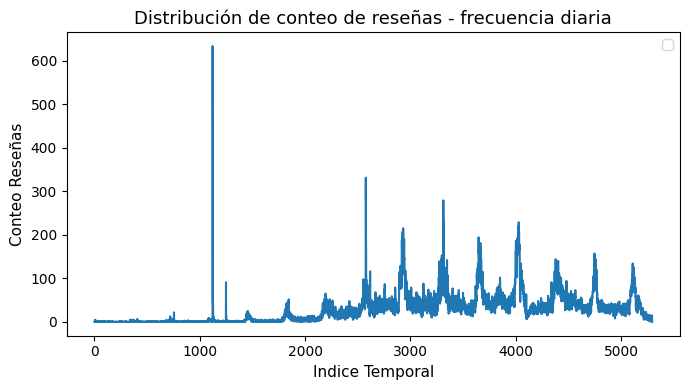

In [28]:
# Daily
fig, ax = plt.subplots(figsize=(7, 4))

# ax.hist(df_daily["review_count"], edgecolor="black", color="steelblue", alpha=0.85)
ax.plot(df_daily["index"], df_daily["review_count"])

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - frecuencia diaria", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1003/526816978.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


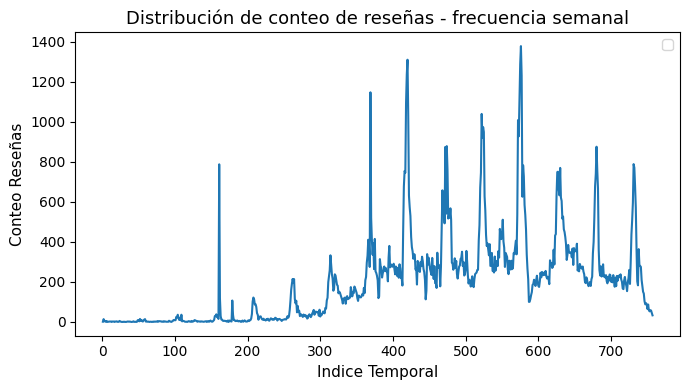

In [27]:
# weekly
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df_weekly["index"], df_weekly["review_count"])

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - frecuencia semanal", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1003/1739028170.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


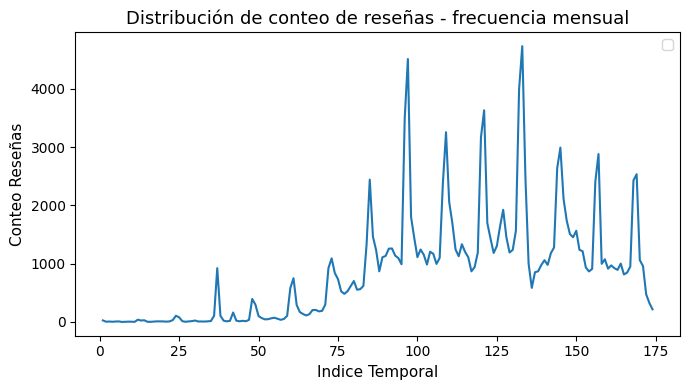

In [26]:
# monthly
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df_monthly["index"], df_monthly["review_count"])


ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - frecuencia mensual", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

Se seleccionará la granulación semanal, pues en la diaria, se identifica una dispersión grande en los datos (tipo outliers), en especial cerca del día 1000, lo que puede generar problemas al entrenar el modelo, por otro lado, en la frecuencia mensual existe poca cantidad de datos. Así que el punto intermedio es la granulación semanal. 

Por lo tanto, se procede a separar el 75 % de los datos para entrenamiento (primeros datos cronológicamente) y el 25% en testeo. 

In [37]:
# Partición de los datos semanales
indice_train = int(len(df_weekly) * 0.75)
train = df_weekly[df_weekly["index"] <= indice_train]
test = df_weekly[df_weekly["index"] > indice_train]

X_train, y_train = train[["index"]], train["review_count"]
X_test, y_test = test[["index"]], test["review_count"]

Luego, se procede a gráficar los datos de entrenamiento y de test

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1003/3793186399.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


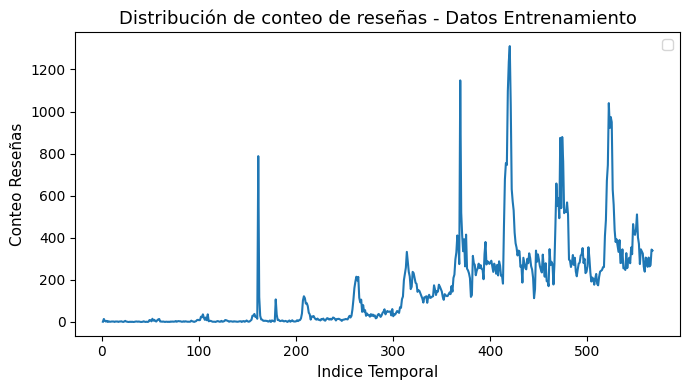

In [43]:
# Gráfico datos Entrenamiento
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(X_train, y_train)

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - Datos Entrenamiento", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1003/871524206.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


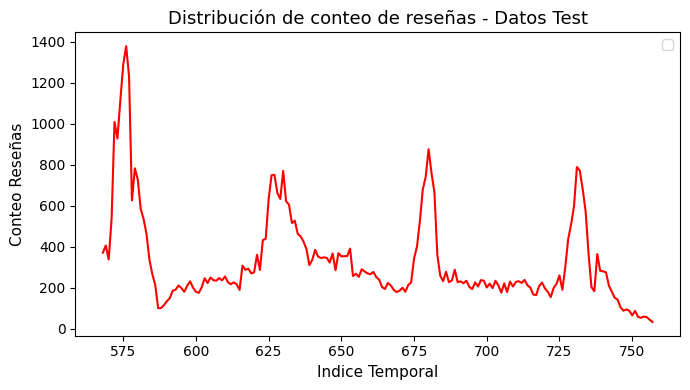

In [42]:
# Gráfico datos Test
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(X_test, y_test, color="red")

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - Datos Test", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()